### Spelling Correction using Jaccard Similarity

### Formula:

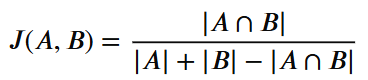

In [1]:
d =["receive","believe","friend","learning","machine",
   "python","science","data","school","college","analysis"] 

In [3]:
# create character groups
def char_group(word,n=2):
    word=word.lower()
    return [word[i:i+1]for i in range(len(word)-n+1)]

In [22]:
char_group("Good Morning",n=2)

['g', 'o', 'o', 'd', ' ', 'm', 'o', 'r', 'n', 'i', 'n']

In [15]:
# Jaccard Similarity
def jaccard_similarity(a,b):
    set1=set(a)
    set2=set(b)
    return len(set1&set2)/len(set1 | set2)

In [18]:
# function to calculate spelling score
def correct_spelling(word,dictionary,n=2):
    word_ngrams = char_group(word,n)
    best_match = None
    best_score = 0

    for correct_word in dictionary:
        correct_ngrams = char_group(correct_word,n)
        score = jaccard_similarity(word_ngrams,correct_ngrams)

        if score > best_score:
            best_score = score
            best_match = correct_word
    return best_match,best_score

In [30]:
wrong_word = ["receiwe","freynd","larning","macheen","scinse"]
for i in wrong_word:
    match,score = correct_spelling(i,d)
    print(f"{i}-->{match}-->(score : {score:.2f})") 

receiwe-->receive-->(score : 0.67)
freynd-->friend-->(score : 0.67)
larning-->learning-->(score : 0.83)
macheen-->machine-->(score : 0.57)
scinse-->science-->(score : 0.80)


In [25]:
a = "receiwe"
b = "receive"
set1=set(a)
set2=set(b)
len(set1&set2) / len(set1 | set2)

0.6666666666666666

In [29]:
set1|set2

{'c', 'e', 'i', 'r', 'v', 'w'}

### Preprocessing Step for messy texts

In [38]:
import re

def preprocess(word):
    word = word.lower()
    word = re.sub(r'[^a-z]','',word)
    return word

In [44]:
preprocess("He@__++llo!!123")

'hello'

In [36]:
def improved_correction(word,dictionary,n=2):
    word = preprocess(word)
    word_ngrams = char_group(word,n)
    best_match = None
    best_score = 0
    
    for correct_word in dictionary:
        correct_clean = preprocess(correct_word)
        correct_ngrams = char_group(correct_word,n)
        score = jaccard_similarity(word_ngrams,correct_ngrams)

        if score > best_score:
            best_score = score
            best_match = correct_word
    return best_match,best_score

In [37]:
wrong_word = ["Recieve!!","Friend123","Machin?","Scince"]
for i in wrong_word:
    match,score = correct_spelling(i,d)
    print(f"{i}-->{match}-->(score : {score:.2f})") 

Recieve!!-->receive-->(score : 0.83)
Friend123-->friend-->(score : 0.62)
Machin?-->machine-->(score : 1.00)
Scince-->science-->(score : 0.80)
